# Random Forest Classification Notebook

This notebook contains three classification tasks using RandomForestClassifier:
1. Normal classification with make_classification
2. IMDB review classification
3. AG News classification

## Simple Explanation
This notebook teaches Random Forest classification in simple steps.
- Part A: Classify normal numeric data made with make_classification.
- Part B-C: Classify IMDB movie reviews (negative or positive).
- Part D: Classify AG News articles into 4 categories.
- Random Forest uses many trees and combines their votes.

## Step 1: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

np.random.seed(42)
print("Libraries imported successfully")

c:\Users\hamen\.pyenv\pyenv-win\versions\3.11.9\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries imported successfully


## Part A: Normal Classification with make_classification

### Easy Note
In numeric classification, each row has feature values.
Random Forest learns from training rows and predicts class labels for new rows.

In [2]:
# Create synthetic classification data
X_num, y_num = make_classification(
    n_samples=3000,
    n_features=24,
    n_informative=12,
    n_redundant=6,
    n_classes=2,
    weights=[0.55, 0.45],
    class_sep=1.1,
    flip_y=0.03,
    random_state=42
)

feature_names = [f"feature_{i}" for i in range(X_num.shape[1])]
df_num = pd.DataFrame(X_num, columns=feature_names)
df_num['target'] = y_num

print('Synthetic dataset shape:', df_num.shape)
print('Class distribution:')
print(df_num['target'].value_counts())
df_num.head()

Synthetic dataset shape: (3000, 25)
Class distribution:
target
0    1663
1    1337
Name: count, dtype: int64


,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_15,feature_16,feature_17,feature_18,feature_19,feature_20,feature_21,feature_22,feature_23,target
0,-3.319311,-1.220885,1.791931,5.813407,0.472927,-1.034279,-2.581157,2.482063,-2.881855,4.034131,...,-11.507638,2.306874,5.610917,-3.371941,3.361164,-1.205762,0.665615,-0.439951,-6.292683,0
1,3.823573,4.659429,0.238436,-4.005702,-2.161242,0.201241,-1.119970,5.791677,-1.888482,3.602531,...,-5.378237,-3.195138,-0.888469,-18.141048,0.533133,-4.421443,-0.347054,4.581183,-3.307542,1
2,-1.137099,-2.284082,-0.096217,6.374640,0.908338,0.447750,0.620431,0.021874,1.454126,5.773753,...,-10.526154,2.291596,2.076143,-4.984471,3.582290,-0.197620,-0.898860,1.215724,-8.914789,0
3,2.493966,-1.839694,-1.166367,8.281868,-4.479719,2.864391,-0.238874,-0.198205,11.487950,0.214479,...,-5.150409,3.845849,-1.743755,-4.955738,0.686252,-5.298747,0.368600,4.480428,1.708098,0
4,1.044287,-1.934431,-0.340797,4.554081,-4.796514,1.451887,-0.202569,-0.640033,9.036831,1.750544,...,-5.787013,3.263371,-2.196581,-4.078421,1.500827,-1.683456,0.044400,3.168058,1.563880,0


In [3]:
X_train_num, X_test_num, y_train_num, y_test_num = train_test_split(
    df_num.drop(columns=['target']),
    df_num['target'],
    test_size=0.2,
    stratify=df_num['target'],
    random_state=42
)

rf_num = RandomForestClassifier(
    n_estimators=300,
    max_depth=14,
    min_samples_split=8,
    min_samples_leaf=3,
    class_weight='balanced_subsample',
    n_jobs=-1,
    random_state=42
)

rf_num.fit(X_train_num, y_train_num)
y_pred_num = rf_num.predict(X_test_num)

acc_num = accuracy_score(y_test_num, y_pred_num)
prec_num = precision_score(y_test_num, y_pred_num)
rec_num = recall_score(y_test_num, y_pred_num)
f1_num = f1_score(y_test_num, y_pred_num)

print(f'Accuracy : {acc_num:.4f}')
print(f'Precision: {prec_num:.4f}')
print(f'Recall   : {rec_num:.4f}')
print(f'F1-Score : {f1_num:.4f}')

Accuracy : 0.9383
Precision: 0.9423
Recall   : 0.9176
F1-Score : 0.9298


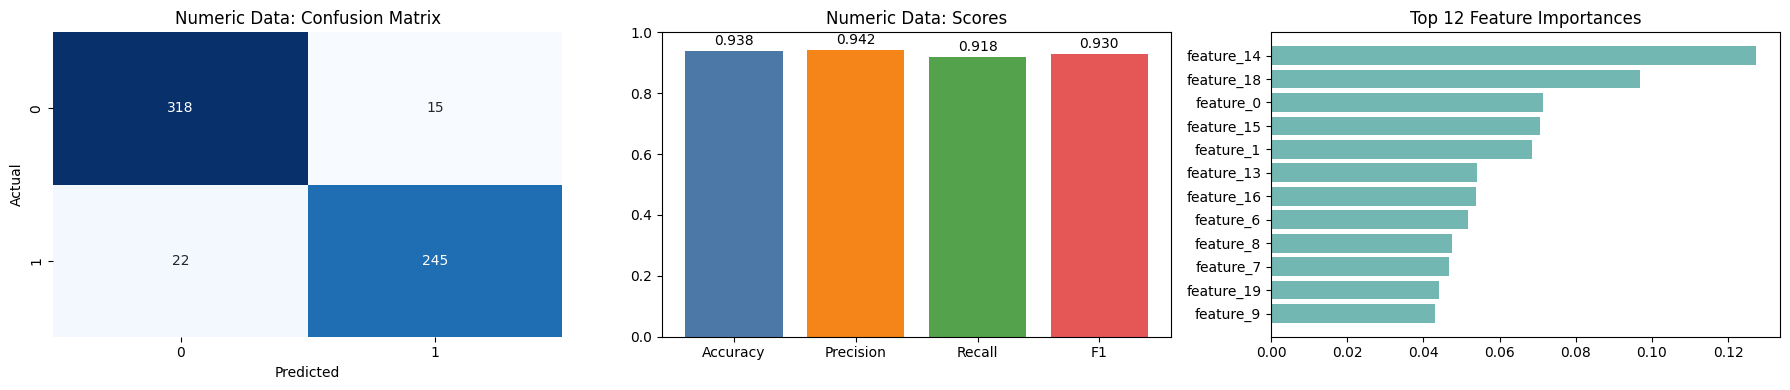

In [4]:
cm_num = confusion_matrix(y_test_num, y_pred_num)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.heatmap(cm_num, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0])
axes[0].set_title('Numeric Data: Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

metric_names = ['Accuracy', 'Precision', 'Recall', 'F1']
metric_scores = [acc_num, prec_num, rec_num, f1_num]
axes[1].bar(metric_names, metric_scores, color=['#4C78A8', '#F58518', '#54A24B', '#E45756'])
axes[1].set_ylim(0, 1)
axes[1].set_title('Numeric Data: Scores')
for i, v in enumerate(metric_scores):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center')

importance_df = pd.DataFrame({
    'feature': X_train_num.columns,
    'importance': rf_num.feature_importances_
}).sort_values('importance', ascending=False).head(12)
axes[2].barh(importance_df['feature'][::-1], importance_df['importance'][::-1], color='#72B7B2')
axes[2].set_title('Top 12 Feature Importances')

plt.tight_layout()
plt.show()

## Part B: Load IMDB and AG News Datasets

In [5]:
import pandas as pd
from datasets import load_dataset

dataset = load_dataset("imdb")

df = pd.DataFrame(dataset["train"])

dataset1 = load_dataset("ag_news")
df1 = pd.DataFrame(dataset1["train"])
df1.head()

,text,label
0,Wall St. Bears Claw Back Into the Black (Reute...,2
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2
3,Iraq Halts Oil Exports from Main Southern Pipe...,2
4,"Oil prices soar to all-time record, posing new...",2


In [6]:
print('IMDB train shape:', df.shape)
print('AG News train shape:', df1.shape)
print('IMDB labels:', sorted(df['label'].unique()))
print('AG News labels:', sorted(df1['label'].unique()))

IMDB train shape: (25000, 2)
AG News train shape: (120000, 2)
IMDB labels: [np.int64(0), np.int64(1)]
AG News labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


## Part C: IMDB Review Classification with Random Forest

### Easy Note
For IMDB text, TF-IDF converts words into numeric vectors.
Random Forest then predicts if the review is negative or positive.

In [7]:
# Use a sampled subset for faster training
imdb_train = pd.DataFrame(dataset['train']).sample(n=7000, random_state=42)
imdb_test = pd.DataFrame(dataset['test']).sample(n=2000, random_state=42)

X_train_imdb = imdb_train['text']
y_train_imdb = imdb_train['label']
X_test_imdb = imdb_test['text']
y_test_imdb = imdb_test['label']

print('IMDB sampled train size:', X_train_imdb.shape[0])
print('IMDB sampled test size :', X_test_imdb.shape[0])

IMDB sampled train size: 7000
IMDB sampled test size : 2000


In [8]:
rf_imdb_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english', max_features=5000, ngram_range=(1, 2), min_df=2)),
    ('model', RandomForestClassifier(
        n_estimators=220,
        max_depth=35,
        min_samples_split=6,
        min_samples_leaf=2,
        class_weight='balanced_subsample',
        n_jobs=-1,
        random_state=42
    ))
])

rf_imdb_pipeline.fit(X_train_imdb, y_train_imdb)
y_pred_imdb = rf_imdb_pipeline.predict(X_test_imdb)

acc_imdb = accuracy_score(y_test_imdb, y_pred_imdb)
prec_imdb = precision_score(y_test_imdb, y_pred_imdb)
rec_imdb = recall_score(y_test_imdb, y_pred_imdb)
f1_imdb = f1_score(y_test_imdb, y_pred_imdb)

print(f'IMDB Accuracy : {acc_imdb:.4f}')
print(f'IMDB Precision: {prec_imdb:.4f}')
print(f'IMDB Recall   : {rec_imdb:.4f}')
print(f'IMDB F1-Score : {f1_imdb:.4f}')

IMDB Accuracy : 0.8350
IMDB Precision: 0.8046
IMDB Recall   : 0.8667
IMDB F1-Score : 0.8345


In [9]:
print('IMDB classification report:')
print(classification_report(y_test_imdb, y_pred_imdb, target_names=['negative', 'positive']))

IMDB classification report:
              precision    recall  f1-score   support

    negative       0.87      0.81      0.84      1040
    positive       0.80      0.87      0.83       960

    accuracy                           0.83      2000
   macro avg       0.84      0.84      0.83      2000
weighted avg       0.84      0.83      0.84      2000



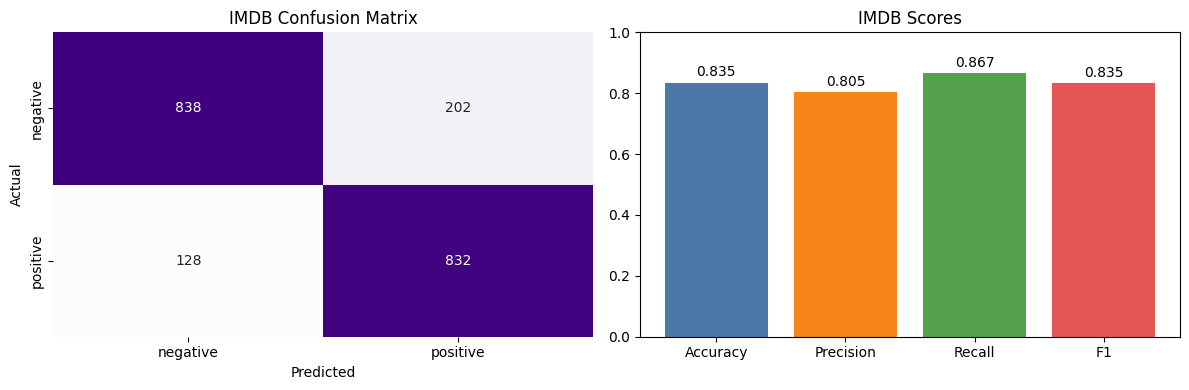

In [10]:
cm_imdb = confusion_matrix(y_test_imdb, y_pred_imdb)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(cm_imdb, annot=True, fmt='d', cmap='Purples', cbar=False, ax=axes[0])
axes[0].set_title('IMDB Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_xticklabels(['negative', 'positive'])
axes[0].set_yticklabels(['negative', 'positive'])

imdb_metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
imdb_scores = [acc_imdb, prec_imdb, rec_imdb, f1_imdb]
axes[1].bar(imdb_metrics, imdb_scores, color=['#4C78A8', '#F58518', '#54A24B', '#E45756'])
axes[1].set_ylim(0, 1)
axes[1].set_title('IMDB Scores')
for i, v in enumerate(imdb_scores):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center')

plt.tight_layout()
plt.show()

## Part D: AG News Classification with Random Forest

### Easy Note
AG News has multiple classes, so this is multiclass classification.
The model outputs one class index, then we map it to class name.

In [11]:
ag_train = pd.DataFrame(dataset1['train']).sample(n=10000, random_state=42)
ag_test = pd.DataFrame(dataset1['test']).sample(n=2500, random_state=42)

X_train_ag = ag_train['text']
y_train_ag = ag_train['label']
X_test_ag = ag_test['text']
y_test_ag = ag_test['label']

class_names_ag = dataset1['train'].features['label'].names
print('AG sampled train size:', X_train_ag.shape[0])
print('AG sampled test size :', X_test_ag.shape[0])
print('AG classes:', class_names_ag)

AG sampled train size: 10000
AG sampled test size : 2500
AG classes: ['World', 'Sports', 'Business', 'Sci/Tech']


In [12]:
rf_ag_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english', max_features=6000, ngram_range=(1, 2), min_df=3)),
    ('model', RandomForestClassifier(
        n_estimators=260,
        max_depth=40,
        min_samples_split=6,
        min_samples_leaf=2,
        class_weight='balanced_subsample',
        n_jobs=-1,
        random_state=42
    ))
])

rf_ag_pipeline.fit(X_train_ag, y_train_ag)
y_pred_ag = rf_ag_pipeline.predict(X_test_ag)

acc_ag = accuracy_score(y_test_ag, y_pred_ag)
prec_ag = precision_score(y_test_ag, y_pred_ag, average='weighted')
rec_ag = recall_score(y_test_ag, y_pred_ag, average='weighted')
f1_ag = f1_score(y_test_ag, y_pred_ag, average='weighted')

print(f'AG News Accuracy : {acc_ag:.4f}')
print(f'AG News Precision: {prec_ag:.4f}')
print(f'AG News Recall   : {rec_ag:.4f}')
print(f'AG News F1-Score : {f1_ag:.4f}')

AG News Accuracy : 0.8184
AG News Precision: 0.8189
AG News Recall   : 0.8184
AG News F1-Score : 0.8177


In [13]:
print('AG News classification report:')
print(classification_report(y_test_ag, y_pred_ag, target_names=class_names_ag))

AG News classification report:
              precision    recall  f1-score   support

       World       0.86      0.82      0.84       638
      Sports       0.85      0.92      0.88       629
    Business       0.80      0.73      0.77       580
    Sci/Tech       0.76      0.80      0.78       653

    accuracy                           0.82      2500
   macro avg       0.82      0.82      0.82      2500
weighted avg       0.82      0.82      0.82      2500



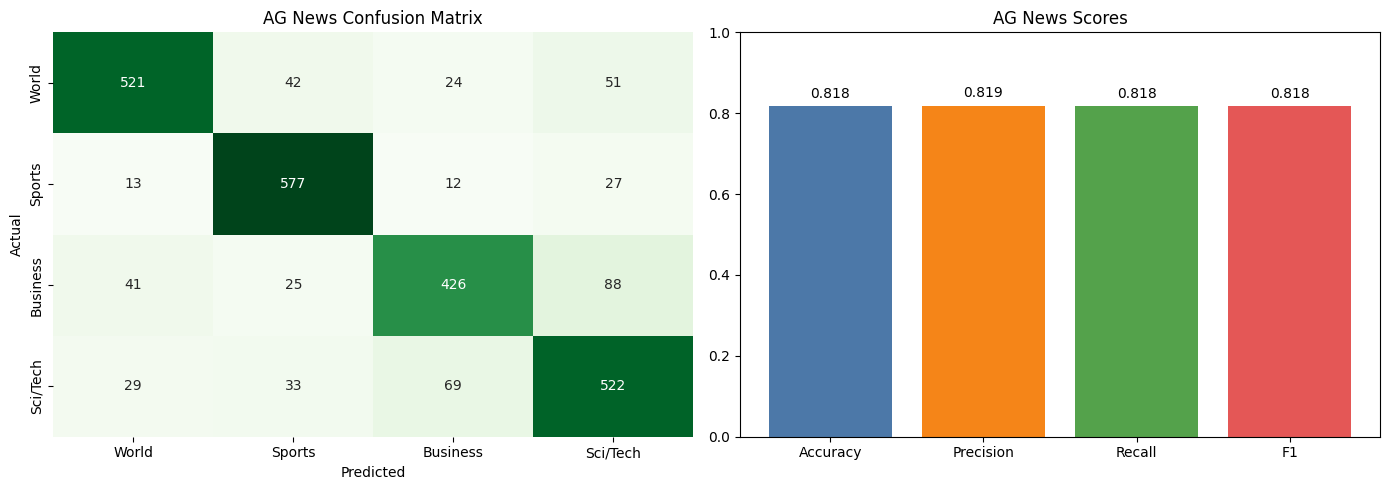

In [14]:
cm_ag = confusion_matrix(y_test_ag, y_pred_ag, labels=list(range(len(class_names_ag))))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm_ag, annot=True, fmt='d', cmap='Greens', cbar=False, ax=axes[0],
            xticklabels=class_names_ag, yticklabels=class_names_ag)
axes[0].set_title('AG News Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

ag_metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
ag_scores = [acc_ag, prec_ag, rec_ag, f1_ag]
axes[1].bar(ag_metrics, ag_scores, color=['#4C78A8', '#F58518', '#54A24B', '#E45756'])
axes[1].set_ylim(0, 1)
axes[1].set_title('AG News Scores')
for i, v in enumerate(ag_scores):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center')

plt.tight_layout()
plt.show()

## Summary

You trained Random Forest classifiers on:
- Numeric synthetic data from make_classification
- IMDB text reviews
- AG News text articles

If training is slow on your machine, reduce sample size, max_features, or n_estimators.

In [15]:
# New data prediction examples
print('--- New Data Predictions (Random Forest) ---')

# 1) Numeric sample prediction
new_numeric_sample = X_test_num.iloc[[0]].copy()
numeric_pred = rf_num.predict(new_numeric_sample)[0]
print('Numeric sample predicted class:', int(numeric_pred))

# 2) New IMDB review prediction
new_imdb_review = "The film had a strong story, great acting, and a satisfying ending."
imdb_pred = rf_imdb_pipeline.predict([new_imdb_review])[0]
imdb_label = 'positive' if imdb_pred == 1 else 'negative'
print('IMDB review prediction:', imdb_label)

# 3) New AG News prediction
new_ag_text = "The football team secured a dramatic win in the championship final."
ag_pred = rf_ag_pipeline.predict([new_ag_text])[0]
print('AG News prediction:', class_names_ag[ag_pred])

--- New Data Predictions (Random Forest) ---
Numeric sample predicted class: 0
IMDB review prediction: positive
AG News prediction: Sports
